<font size=3;>
<p style="text-align: right;"> Lab Solution --- <b>NOT FOR DISTRIBUTION!</b> </p>
</font>

# Lab K in-class: Linear Regression

## Setup

In [1]:
# Import some useful functions
from numpy import *
from numpy.random import *
from datascience import *
from statsmodels.formula.api import *

# Define some useful functions
def correlation(array_1, array_2):
    return corrcoef(array_1, array_2).item(1)

# Customize look of graphics
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['figure.dpi'] = 60
%matplotlib inline

# Force display of all values 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Hide some unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")
import numpy
numpy.int = numpy.int_

## More Investing in Residential Real Estate

### Business Decision

A real estate broker at a San Francisco firm wants to evaluate prices of new properties becoming available.  She needs a model to predict prices based on historical property sales data.

### Data

Retrieve data from file 'redfin.csv'.  Show the first few properties.

In [2]:
data = Table().read_table('redfin.csv')
data

SALE_TYPE,SOLD_DATE,PROPERTY_TYPE,ADDRESS,CITY,STATE,ZIP,PRICE,BEDS,BATHS,LOCATION,SQUARE_FEET,LOT_SIZE,YEAR_BUILT,DAYS_ON_MARKET,$/SQUARE FEET,HOA/MONTH,STATUS,NEXT_OPEN_HOUSE_START_TIME,NEXT_OPEN_HOUSE_END_TIME,URL,SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE
MLS Listing,nan,Condo/Co-op,725 Pine St #204,San Francisco,CA,94108,193724,0,1,Downtown,288,nan,1920,116,673,507,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/725-Pine-St-94108 ...,San Francisco MLS,453971,N,Y,37.791,-122.408
MLS Listing,nan,Condo/Co-op,260 King St #401,San Francisco,CA,94107,212624,0,1,Mission Bay,703,nan,2004,18,302,750,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/260-King-St-94107 ...,San Francisco MLS,457588,N,Y,37.7772,-122.394
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #203,San Francisco,CA,94124,330000,1,1,Silver Terrace,606,nan,2003,21,545,336,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457543,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #406,San Francisco,CA,94124,340000,1,1,Silver Terrace,550,nan,2003,21,618,311,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457542,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,1450 Post St #412,San Francisco,CA,94109,350000,1,1,Lower Pacific Height,715,nan,1992,12,490,4544,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1450-Post-St-9410 ...,San Francisco MLS,455844,N,Y,37.7864,-122.426
MLS Listing,nan,Townhouse,100 Otter Cove Ter,San Francisco,CA,94134,371790,3,3.5,Bayview Heights,1525,9717,2010,20,244,383,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/100-Otter-Cove-Te ...,San Francisco MLS,457563,N,Y,37.7122,-122.395
MLS Listing,nan,Condo/Co-op,1200 California St Unit MR11,San Francisco,CA,94109,379000,0,1,Nob Hill,260,nan,nan,14,1458,303,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1200-California-S ...,San Francisco MLS,457800,N,Y,37.7917,-122.415
MLS Listing,nan,Condo/Co-op,370 Imperial Way #113,DALY CITY,CA,94015,388000,1,1,DALY CITY,717,nan,1974,167,541,352,Active,nan,nan,http://www.redfin.com/CA/Daly-City/370-Imperial-Way-9401 ...,MLSListings,ML81633310,N,Y,37.6657,-122.464
MLS Listing,nan,Condo/Co-op,195 7th St #307,San Francisco,CA,94103,399000,0,1,South of Market,298,nan,1991,21,1339,309,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/195-7th-St-94103/ ...,San Francisco MLS,457449,N,Y,37.7783,-122.409
MLS Listing,nan,Condo/Co-op,1155 Leavenworth St #7,San Francisco,CA,94109,405000,0,1,Nob Hill,320,nan,1911,4,1266,290,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/1155-Leavenworth- ...,San Francisco MLS,456796,N,Y,37.792,-122.416


### Analysis: Descriptive Statistics & Data Visualization

Calculate and show the median, mean, and standard deviation of price.

In [3]:
median(data.column('PRICE'))
mean(data.column('PRICE'))
std(data.column('PRICE'))

1299000.0

1972152.8288854002

2354321.3196662059

Visualize the correlation between price and square feet as a scatterplot.

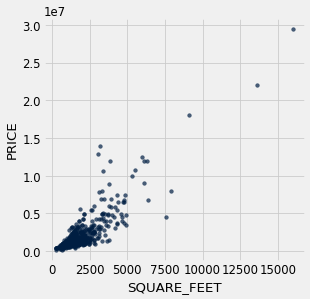

In [5]:
data.select('SQUARE_FEET','PRICE').scatter('SQUARE_FEET')

### Analysis: Simple Linear Regression

#### Model

Build a simple linear regression model to predict price based on square feet.
Show the model goodness of fit (R^2).
Show the model parameter values (intercept and coefficient of square feet).

$$
\textit{price} \;=\; -702607.21 \;+\; 1526.17 \times \textit{square feet}
$$

In [6]:
model = ols('PRICE ~ SQUARE_FEET', data).fit()
model.rsquared
model.params
i = model.params[0]
c = model.params[1]
i
c

0.73265846509786892

Intercept     -702607.212404
SQUARE_FEET      1526.126125
dtype: float64

-702607.21240404435

1526.1261248306005

Visualize the model goodness of fit as a scatterplot with best fit line.

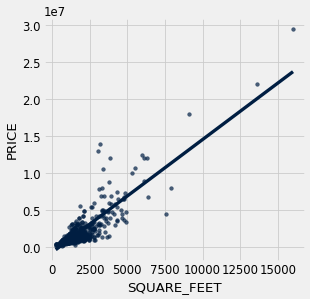

In [7]:
data.select('SQUARE_FEET','PRICE').scatter('SQUARE_FEET', fit_line=True)

#### Predictions

Use the model parameters to predict the price of a 14,000 square feet property.

In [8]:
sqft = 14000
price_predicted = i + c*sqft
price_predicted

20663158.535224363

Use the model parameters to predict the price of a 3,000 square feet property.

In [9]:
sqft = 3000
price_predicted = i + c*sqft
price_predicted

3875771.1620877571

Use the model parameters to predict the price of a 600 square feet property.

In [10]:
sqft = 600
price_predicted = i + c*sqft
price_predicted

213068.46249431593

Use the model parameters to predict the price of a 400 square feet property.

In [11]:
sqft = 400
price_predicted = i + c*sqft
price_predicted

-92156.762471804162

Use the predict method to predict the prices of 14,000, 3,000, 600, and 400 square feet properties.

In [12]:
model.predict(Table().with_column('SQUARE_FEET', make_array(14000, 3000, 600, 400)))

0    2.066316e+07
1    3.875771e+06
2    2.130685e+05
3   -9.215676e+04
dtype: float64

Use the predict method to predict the price of 3,000 square feet property.

In [13]:
model.predict(Table().with_column('SQUARE_FEET', 3000))

0    3.875771e+06
dtype: float64

#### Back-Predictions

Back-predict prices of all the properties.

In [14]:
data = data.with_column('price_predicted', model.predict(data))
data

SALE_TYPE,SOLD_DATE,PROPERTY_TYPE,ADDRESS,CITY,STATE,ZIP,PRICE,BEDS,BATHS,LOCATION,SQUARE_FEET,LOT_SIZE,YEAR_BUILT,DAYS_ON_MARKET,$/SQUARE FEET,HOA/MONTH,STATUS,NEXT_OPEN_HOUSE_START_TIME,NEXT_OPEN_HOUSE_END_TIME,URL,SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE,price_predicted
MLS Listing,nan,Condo/Co-op,725 Pine St #204,San Francisco,CA,94108,193724,0,1,Downtown,288,nan,1920,116,673,507,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/725-Pine-St-94108 ...,San Francisco MLS,453971,N,Y,37.791,-122.408,-263083
MLS Listing,nan,Condo/Co-op,260 King St #401,San Francisco,CA,94107,212624,0,1,Mission Bay,703,nan,2004,18,302,750,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/260-King-St-94107 ...,San Francisco MLS,457588,N,Y,37.7772,-122.394,370259
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #203,San Francisco,CA,94124,330000,1,1,Silver Terrace,606,nan,2003,21,545,336,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457543,N,Y,37.7327,-122.404,222225
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #406,San Francisco,CA,94124,340000,1,1,Silver Terrace,550,nan,2003,21,618,311,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457542,N,Y,37.7327,-122.404,136762
MLS Listing,nan,Condo/Co-op,1450 Post St #412,San Francisco,CA,94109,350000,1,1,Lower Pacific Height,715,nan,1992,12,490,4544,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1450-Post-St-9410 ...,San Francisco MLS,455844,N,Y,37.7864,-122.426,388573
MLS Listing,nan,Townhouse,100 Otter Cove Ter,San Francisco,CA,94134,371790,3,3.5,Bayview Heights,1525,9717,2010,20,244,383,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/100-Otter-Cove-Te ...,San Francisco MLS,457563,N,Y,37.7122,-122.395,1.62474e+06
MLS Listing,nan,Condo/Co-op,1200 California St Unit MR11,San Francisco,CA,94109,379000,0,1,Nob Hill,260,nan,nan,14,1458,303,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1200-California-S ...,San Francisco MLS,457800,N,Y,37.7917,-122.415,-305814
MLS Listing,nan,Condo/Co-op,370 Imperial Way #113,DALY CITY,CA,94015,388000,1,1,DALY CITY,717,nan,1974,167,541,352,Active,nan,nan,http://www.redfin.com/CA/Daly-City/370-Imperial-Way-9401 ...,MLSListings,ML81633310,N,Y,37.6657,-122.464,391625
MLS Listing,nan,Condo/Co-op,195 7th St #307,San Francisco,CA,94103,399000,0,1,South of Market,298,nan,1991,21,1339,309,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/195-7th-St-94103/ ...,San Francisco MLS,457449,N,Y,37.7783,-122.409,-247822
MLS Listing,nan,Condo/Co-op,1155 Leavenworth St #7,San Francisco,CA,94109,405000,0,1,Nob Hill,320,nan,1911,4,1266,290,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/1155-Leavenworth- ...,San Francisco MLS,456796,N,Y,37.792,-122.416,-214247


Visualize the prices and predicted prices vs. square feet as a scatterplot.

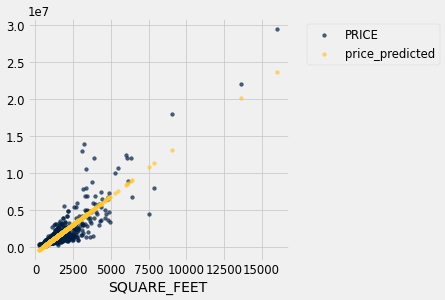

In [15]:
data.select('SQUARE_FEET','PRICE','price_predicted').scatter('SQUARE_FEET')

### Analysis: Multiple Linear Regression

#### Data (for a new model)

Filter the data to include only properties that are not missing values for BEDS.  
You can get the those properties like this: `data = data.where(~isnan(data.column('BEDS')))`

Filter the data to include only properties that are not missing values for BATHS.  
You can get the those properties like this: `data = data.where(~isnan(data.column('BATHS')))`

Drop the price_predicted variable.

Show the first few properties.

In [16]:
data = data.where(~isnan(data.column('BEDS')))
data = data.where(~isnan(data.column('BATHS')))
data = data.drop('price_predicted')
data

SALE_TYPE,SOLD_DATE,PROPERTY_TYPE,ADDRESS,CITY,STATE,ZIP,PRICE,BEDS,BATHS,LOCATION,SQUARE_FEET,LOT_SIZE,YEAR_BUILT,DAYS_ON_MARKET,$/SQUARE FEET,HOA/MONTH,STATUS,NEXT_OPEN_HOUSE_START_TIME,NEXT_OPEN_HOUSE_END_TIME,URL,SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE
MLS Listing,nan,Condo/Co-op,725 Pine St #204,San Francisco,CA,94108,193724,0,1,Downtown,288,nan,1920,116,673,507,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/725-Pine-St-94108 ...,San Francisco MLS,453971,N,Y,37.791,-122.408
MLS Listing,nan,Condo/Co-op,260 King St #401,San Francisco,CA,94107,212624,0,1,Mission Bay,703,nan,2004,18,302,750,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/260-King-St-94107 ...,San Francisco MLS,457588,N,Y,37.7772,-122.394
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #203,San Francisco,CA,94124,330000,1,1,Silver Terrace,606,nan,2003,21,545,336,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457543,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #406,San Francisco,CA,94124,340000,1,1,Silver Terrace,550,nan,2003,21,618,311,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457542,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,1450 Post St #412,San Francisco,CA,94109,350000,1,1,Lower Pacific Height,715,nan,1992,12,490,4544,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1450-Post-St-9410 ...,San Francisco MLS,455844,N,Y,37.7864,-122.426
MLS Listing,nan,Townhouse,100 Otter Cove Ter,San Francisco,CA,94134,371790,3,3.5,Bayview Heights,1525,9717,2010,20,244,383,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/100-Otter-Cove-Te ...,San Francisco MLS,457563,N,Y,37.7122,-122.395
MLS Listing,nan,Condo/Co-op,1200 California St Unit MR11,San Francisco,CA,94109,379000,0,1,Nob Hill,260,nan,nan,14,1458,303,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1200-California-S ...,San Francisco MLS,457800,N,Y,37.7917,-122.415
MLS Listing,nan,Condo/Co-op,370 Imperial Way #113,DALY CITY,CA,94015,388000,1,1,DALY CITY,717,nan,1974,167,541,352,Active,nan,nan,http://www.redfin.com/CA/Daly-City/370-Imperial-Way-9401 ...,MLSListings,ML81633310,N,Y,37.6657,-122.464
MLS Listing,nan,Condo/Co-op,195 7th St #307,San Francisco,CA,94103,399000,0,1,South of Market,298,nan,1991,21,1339,309,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/195-7th-St-94103/ ...,San Francisco MLS,457449,N,Y,37.7783,-122.409
MLS Listing,nan,Condo/Co-op,1155 Leavenworth St #7,San Francisco,CA,94109,405000,0,1,Nob Hill,320,nan,1911,4,1266,290,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/1155-Leavenworth- ...,San Francisco MLS,456796,N,Y,37.792,-122.416


#### Model

Build a multiple linear regression model to predict price based on square feet, number of beds, and number of baths.  
You can specify the outcome variable and predictor variables like this: `'PRICE ~ SQUARE_FEET + BEDS + BATHS'`

Show the model goodness of fit (R^2).

Show the model parameter values (intercept and coefficients).

$$
\textit{price} \;=\; -64046.77 \;+\; 1990.33 \times \textit{square feet} \;+\; -586503.50 \times \textit{beds} \;+\; 11648.71 \times \textit{baths}
$$

In [18]:
model = ols('PRICE ~ SQUARE_FEET + BEDS + BATHS', data).fit()
model.rsquared
model.params

0.79203339411953366

Intercept      -64046.770270
SQUARE_FEET      1990.330634
BEDS          -586503.502539
BATHS           11648.711462
dtype: float64

#### Predictions

Use the predict method to predict the price of 3,000 square feet, 2 bed, 2 bath property.  
Use the predict method to predict the price of 3,000 square feet, 3 bed, 2 bath property.  
Use the predict method to predict the price of 4,000 square feet, 2 bed, 2 bath property.  
Use the predict method to predict the price of 4,000 square feet, 3 bed, 2 bath property.

In [19]:
model.predict(Table().with_columns('SQUARE_FEET', 3000, 'BEDS', 2, 'BATHS', 2))
model.predict(Table().with_columns('SQUARE_FEET', 3000, 'BEDS', 3, 'BATHS', 2))
model.predict(Table().with_columns('SQUARE_FEET', 4000, 'BEDS', 2, 'BATHS', 2))
model.predict(Table().with_columns('SQUARE_FEET', 4000, 'BEDS', 3, 'BATHS', 2))

0    4.757236e+06
dtype: float64

0    4.170732e+06
dtype: float64

0    6.747566e+06
dtype: float64

0    6.161063e+06
dtype: float64

#### Back-Predictions
Back-predict prices of all the properties.

In [20]:
data = data.with_column('price_predicted', model.predict(data))
data

SALE_TYPE,SOLD_DATE,PROPERTY_TYPE,ADDRESS,CITY,STATE,ZIP,PRICE,BEDS,BATHS,LOCATION,SQUARE_FEET,LOT_SIZE,YEAR_BUILT,DAYS_ON_MARKET,$/SQUARE FEET,HOA/MONTH,STATUS,NEXT_OPEN_HOUSE_START_TIME,NEXT_OPEN_HOUSE_END_TIME,URL,SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE,price_predicted
MLS Listing,nan,Condo/Co-op,725 Pine St #204,San Francisco,CA,94108,193724,0,1,Downtown,288,nan,1920,116,673,507,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/725-Pine-St-94108 ...,San Francisco MLS,453971,N,Y,37.791,-122.408,520817
MLS Listing,nan,Condo/Co-op,260 King St #401,San Francisco,CA,94107,212624,0,1,Mission Bay,703,nan,2004,18,302,750,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/260-King-St-94107 ...,San Francisco MLS,457588,N,Y,37.7772,-122.394,1.3468e+06
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #203,San Francisco,CA,94124,330000,1,1,Silver Terrace,606,nan,2003,21,545,336,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457543,N,Y,37.7327,-122.404,567239
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #406,San Francisco,CA,94124,340000,1,1,Silver Terrace,550,nan,2003,21,618,311,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457542,N,Y,37.7327,-122.404,455780
MLS Listing,nan,Condo/Co-op,1450 Post St #412,San Francisco,CA,94109,350000,1,1,Lower Pacific Height,715,nan,1992,12,490,4544,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1450-Post-St-9410 ...,San Francisco MLS,455844,N,Y,37.7864,-122.426,784185
MLS Listing,nan,Townhouse,100 Otter Cove Ter,San Francisco,CA,94134,371790,3,3.5,Bayview Heights,1525,9717,2010,20,244,383,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/100-Otter-Cove-Te ...,San Francisco MLS,457563,N,Y,37.7122,-122.395,1.25247e+06
MLS Listing,nan,Condo/Co-op,1200 California St Unit MR11,San Francisco,CA,94109,379000,0,1,Nob Hill,260,nan,nan,14,1458,303,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1200-California-S ...,San Francisco MLS,457800,N,Y,37.7917,-122.415,465088
MLS Listing,nan,Condo/Co-op,370 Imperial Way #113,DALY CITY,CA,94015,388000,1,1,DALY CITY,717,nan,1974,167,541,352,Active,nan,nan,http://www.redfin.com/CA/Daly-City/370-Imperial-Way-9401 ...,MLSListings,ML81633310,N,Y,37.6657,-122.464,788166
MLS Listing,nan,Condo/Co-op,195 7th St #307,San Francisco,CA,94103,399000,0,1,South of Market,298,nan,1991,21,1339,309,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/195-7th-St-94103/ ...,San Francisco MLS,457449,N,Y,37.7783,-122.409,540720
MLS Listing,nan,Condo/Co-op,1155 Leavenworth St #7,San Francisco,CA,94109,405000,0,1,Nob Hill,320,nan,1911,4,1266,290,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/1155-Leavenworth- ...,San Francisco MLS,456796,N,Y,37.792,-122.416,584508


Visualize the prices and predicted prices vs. square feet as a scatterplot.

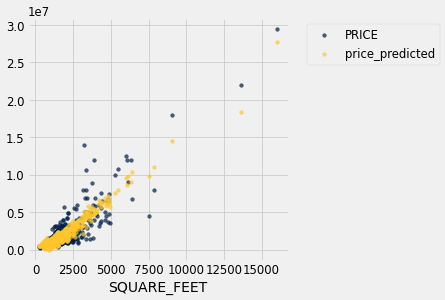

In [21]:
data.select('SQUARE_FEET','PRICE','price_predicted').scatter('SQUARE_FEET')

Visualize the prices and predicted prices vs. number of beds as a scatterplot.

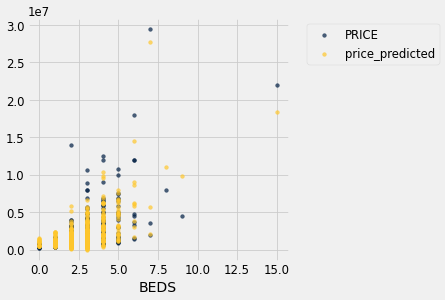

In [22]:
data.select('BEDS','PRICE','price_predicted').scatter('BEDS')

Visualize the prices and predicted prices vs. number of baths as a scatterplot.

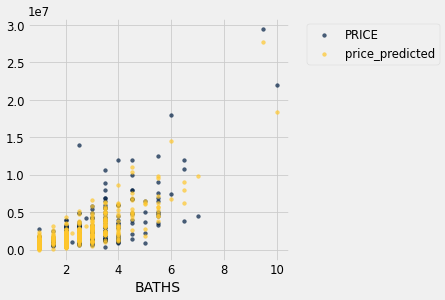

In [23]:
data.select('BATHS','PRICE','price_predicted').scatter('BATHS')

### Analysis: Multiple Linear Regression with Dummy Variables

#### Data (for a new model)

Drop the price_predicted variable.

In [24]:
data = data.drop('price_predicted')
data

SALE_TYPE,SOLD_DATE,PROPERTY_TYPE,ADDRESS,CITY,STATE,ZIP,PRICE,BEDS,BATHS,LOCATION,SQUARE_FEET,LOT_SIZE,YEAR_BUILT,DAYS_ON_MARKET,$/SQUARE FEET,HOA/MONTH,STATUS,NEXT_OPEN_HOUSE_START_TIME,NEXT_OPEN_HOUSE_END_TIME,URL,SOURCE,MLS#,FAVORITE,INTERESTED,LATITUDE,LONGITUDE
MLS Listing,nan,Condo/Co-op,725 Pine St #204,San Francisco,CA,94108,193724,0,1,Downtown,288,nan,1920,116,673,507,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/725-Pine-St-94108 ...,San Francisco MLS,453971,N,Y,37.791,-122.408
MLS Listing,nan,Condo/Co-op,260 King St #401,San Francisco,CA,94107,212624,0,1,Mission Bay,703,nan,2004,18,302,750,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/260-King-St-94107 ...,San Francisco MLS,457588,N,Y,37.7772,-122.394
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #203,San Francisco,CA,94124,330000,1,1,Silver Terrace,606,nan,2003,21,545,336,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457543,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,901 Bayshore Blvd #406,San Francisco,CA,94124,340000,1,1,Silver Terrace,550,nan,2003,21,618,311,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/901-Bayshore-Blvd ...,San Francisco MLS,457542,N,Y,37.7327,-122.404
MLS Listing,nan,Condo/Co-op,1450 Post St #412,San Francisco,CA,94109,350000,1,1,Lower Pacific Height,715,nan,1992,12,490,4544,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1450-Post-St-9410 ...,San Francisco MLS,455844,N,Y,37.7864,-122.426
MLS Listing,nan,Townhouse,100 Otter Cove Ter,San Francisco,CA,94134,371790,3,3.5,Bayview Heights,1525,9717,2010,20,244,383,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/100-Otter-Cove-Te ...,San Francisco MLS,457563,N,Y,37.7122,-122.395
MLS Listing,nan,Condo/Co-op,1200 California St Unit MR11,San Francisco,CA,94109,379000,0,1,Nob Hill,260,nan,nan,14,1458,303,Active,nan,nan,http://www.redfin.com/CA/San-Francisco/1200-California-S ...,San Francisco MLS,457800,N,Y,37.7917,-122.415
MLS Listing,nan,Condo/Co-op,370 Imperial Way #113,DALY CITY,CA,94015,388000,1,1,DALY CITY,717,nan,1974,167,541,352,Active,nan,nan,http://www.redfin.com/CA/Daly-City/370-Imperial-Way-9401 ...,MLSListings,ML81633310,N,Y,37.6657,-122.464
MLS Listing,nan,Condo/Co-op,195 7th St #307,San Francisco,CA,94103,399000,0,1,South of Market,298,nan,1991,21,1339,309,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/195-7th-St-94103/ ...,San Francisco MLS,457449,N,Y,37.7783,-122.409
MLS Listing,nan,Condo/Co-op,1155 Leavenworth St #7,San Francisco,CA,94109,405000,0,1,Nob Hill,320,nan,1911,4,1266,290,Active,May-27-2017 02:00 PM,May-27-2017 04:00 PM,http://www.redfin.com/CA/San-Francisco/1155-Leavenworth- ...,San Francisco MLS,456796,N,Y,37.792,-122.416


#### Dummy Variables

Show the domain of the PROPERTY_TYPE variable like this: `unique(data.column('PROPERTY_TYPE'))`

In [25]:
unique(data.column('PROPERTY_TYPE'))

array(['Condo/Co-op', 'Single Family Residential', 'Townhouse'],
      dtype='<U25')

#### Model with Automatic Conversion to Dummy Variables

Build a multiple linear regression model to predict price based on square feet, number of beds, and number of baths,
whether or not the property is a single family residence, and whether or not the property is a townhouse.  Use PROPERTY_TYPE variable.

Show the model goodness of fit (R^2).

Show the model parameter values (intercept and coefficients).

$$
\textit{price} \;=\; -139693.79 \;+\; 1963.30 \times \textit{square feet} \;+\; -401079.11 \times \textit{beds} \;+\; -16637.97 \times \textit{baths} \;+\; -717094.49 \times \textit{sfr} \;+\; -466476.61 \times \textit{th}
$$

In [26]:
model = ols('PRICE ~ SQUARE_FEET + BEDS + BATHS + PROPERTY_TYPE', data).fit()
model.rsquared
model.params

0.80645141540040188

Intercept                                    -139693.792538
PROPERTY_TYPE[T.Single Family Residential]   -717094.489362
PROPERTY_TYPE[T.Townhouse]                   -466476.613617
SQUARE_FEET                                     1963.303786
BEDS                                         -401079.105533
BATHS                                         -16637.971785
dtype: float64

#### Predictions with Automatic Conversion to Dummy Variables

Use the predict method to predict the price of 3,000 square feet, 3 bed, 2 bath, Condo/Co-op property.  
Use the predict method to predict the price of 3,000 square feet, 3 bed, 2 bath, single family residence property.  
Use the predict method to predict the price of 3,000 square feet, 3 bed, 2 bath, townhouse property.

In [27]:
model.predict(Table().with_columns('SQUARE_FEET', 3000, 'BEDS', 3, 'BATHS', 2, 'PROPERTY_TYPE', 'Condo/Co-op'))
model.predict(Table().with_columns('SQUARE_FEET', 3000, 'BEDS', 3, 'BATHS', 2, 'PROPERTY_TYPE', 'Single Family Residential'))
model.predict(Table().with_columns('SQUARE_FEET', 3000, 'BEDS', 3, 'BATHS', 2, 'PROPERTY_TYPE', 'Townhouse'))

0    4.513704e+06
dtype: float64

0    3.796610e+06
dtype: float64

0    4.047228e+06
dtype: float64

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised November 7, 2023
</span>
</p>